In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import sys
from os import path, makedirs
from datetime import datetime
import pickle

# local imports
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config_new import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers_new import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
from matplotlib.patches import Patch

plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [3]:
show_plot = True


save_fig = True
save_fig_base_dir = "/exp/sbnd/data/users/munjung/xsec/PLOTS/numuCC_1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, f"dent_nus-{today_str}")
if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)


save_content = True
save_content_base_dir = "/exp/sbnd/data/users/munjung/xsec/RESULTS/numuCC_1p0pi"
save_content_dir = path.join(save_content_base_dir, f"dent_nus-{today_str}")
if save_content:
    if not path.exists(save_content_dir):
        makedirs(save_content_dir)
    print("saving nevts in ", save_content_dir)

saving plots in  /exp/sbnd/data/users/munjung/xsec/PLOTS/numuCC_1p0pi/dent_nus-20260506
saving nevts in  /exp/sbnd/data/users/munjung/xsec/RESULTS/numuCC_1p0pi/dent_nus-20260506


In [ ]:
# MC
df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102644__sel_all-mc-BNB_cosmics"
keys2load_offbeam = ['hdr', 'evt', 'trk']
mc_dfs = dfs_from_dir(search_dir=df_dir, filename_str="sel_all-mc-BNB_cosmics_10", keys2load=keys2load_offbeam, n_max_concat=999)

# Data
data_file = path.join(file_dir, "data", "BNB", "_Fixed_all.df")
data_dfs = load_dfs(data_file, 
                    ['evt', 'trk', 'hdr', 'bnbpot'], 
                    n_max_concat=n_max_concat)

# Intime
df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime"
keys2load_offbeam = ['hdr', 'evt', 'trk']
intime_dfs = dfs_from_dir(search_dir=df_dir, filename_str="sel_all-mc-Intime_10", keys2load=keys2load_offbeam, n_max_concat=999)

# Offbeam
df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight"
keys2load_offbeam = ['hdr', 'evt', 'trk']
offbeam_dfs = dfs_from_dir(search_dir=df_dir, filename_str="sel_all-data-OffBeamLight_10", keys2load=keys2load_offbeam, n_max_concat=999)

# Dirt
df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_114032__sel_all-mc-dirt"
keys2load_offbeam = ['hdr', 'evt', 'trk']
dirt_dfs = dfs_from_dir(search_dir=df_dir, filename_str="sel_all-mc-dirt_10", keys2load=keys2load_offbeam, n_max_concat=999)

Found 111 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102644__sel_all-mc-BNB_cosmics/sel_all-mc-BNB_cosmics_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102644__sel_all-mc-BNB_cosmics/sel_all-mc-BNB_cosmics_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102644__sel_all-mc-BNB_cosmics/sel_all-mc-BNB_cosmics_1000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102644__sel_all-mc-BNB_cosmics/sel_all-mc-BNB_cosmics_1001.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102644__sel_all-mc-BNB_cosmics/sel_all-mc-BNB_cosmics_1002.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102644__sel_all-mc-BNB_cosmics/sel_all-mc-BNB_cosmics_1003.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102644__sel_all-mc-BNB_cosmics/sel_all-mc-BNB_cosmics_1004.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102644__sel_a

100%|██████████| 111/111 [01:52<00:00,  1.01s/it]


Found 11 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_104.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_105.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_106.df', '/pnfs/sbnd/scratch/users/munjung/ca

100%|██████████| 11/11 [00:24<00:00,  2.26s/it]


Found 11 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_104.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_105.df', '/pnfs/sbnd/scratch/users/munjung/cafpy

100%|██████████| 11/11 [00:26<00:00,  2.41s/it]


Found 11 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_114032__sel_all-mc-dirt/sel_all-mc-dirt_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_114032__sel_all-mc-dirt/sel_all-mc-dirt_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_114032__sel_all-mc-dirt/sel_all-mc-dirt_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_114032__sel_all-mc-dirt/sel_all-mc-dirt_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_114032__sel_all-mc-dirt/sel_all-mc-dirt_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_114032__sel_all-mc-dirt/sel_all-mc-dirt_104.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_114032__sel_all-mc-dirt/sel_all-mc-dirt_105.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_114032__sel_all-mc-dirt/sel_all-mc-dirt_106.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_114032

100%|██████████| 11/11 [00:29<00:00,  2.67s/it]


In [ ]:
data_file = path.join(file_dir, "data", "BNB", "_Fixed_all.df")
data_dfs = load_dfs(data_file, 
                    ['evt', 'trk', 'hdr', 'bnbpot'], 
                    n_max_concat=n_max_concat)
data_evt_df = data_dfs['evt']
data_trk_df = data_dfs['trk']
data_hdr_df = data_dfs['hdr']

In [ ]:
mc_df = mc_dfs["evt"]
mc_trk_df = mc_dfs["trk"]
mc_hdr_df = mc_dfs["hdr"]   

data_df     = data_dfs['evt']      # BNB on-beam data
data_trk_df = data_dfs['trk']
data_hdr_df = data_dfs['hdr']

intime_df = intime_dfs["evt"]
intime_trk_df = intime_dfs["trk"]
intime_hdr_df = intime_dfs["hdr"]

offbeam_df = offbeam_dfs["evt"]
offbeam_trk_df = offbeam_dfs["trk"]
offbeam_hdr_df = offbeam_dfs["hdr"]

dirt_df = dirt_dfs["evt"]
dirt_trk_df = dirt_dfs["trk"]
dirt_hdr_df = dirt_dfs["hdr"]

In [19]:
# ── Exposure / POT scaling ────────────────────────────────────────────
# BNB on-beam data is the reference exposure; all MC samples are scaled to it.

# BNB on-beam data — weight = 1 (defines the reference POT)
data_tot_pot = data_hdr_df['pot'].sum()
data_df["pot_weight"]     = 1.0
data_trk_df["pot_weight"] = 1.0
data_gates   = data_hdr_df.nbnbinfo.sum()
pot_str = get_pot_str(data_tot_pot)
print(f"BNB data     tot POT  : {data_tot_pot:.3e}  tot gates: {data_gates:.2e}")

# BNB MC — scale to data POT
mc_tot_pot   = mc_hdr_df['pot'].sum()
mc_pot_scale = data_tot_pot / mc_tot_pot if mc_tot_pot > 0 else 0.
mc_df["pot_weight"]     = mc_pot_scale
mc_trk_df["pot_weight"] = mc_pot_scale
print(f"BNB MC       tot POT  : {mc_tot_pot:.3e}  ->  scale = {mc_pot_scale:.3e}")

# Dirt — scale to data POT
dirt_tot_pot   = dirt_hdr_df['pot'].sum()
dirt_pot_scale = data_tot_pot / dirt_tot_pot if dirt_tot_pot > 0 else 0.
dirt_df["pot_weight"]     = dirt_pot_scale
dirt_trk_df["pot_weight"] = dirt_pot_scale
print(f"Dirt         tot POT  : {dirt_tot_pot:.3e}  ->  scale = {dirt_pot_scale:.3e}")

# Offbeam (data cosmics) — gate-normalised to BNB data gates
f = 0.08  # fraction correction (beam-off coincident with beam-on)
offbeam_gates = offbeam_hdr_df.loc[offbeam_hdr_df['first_in_subrun'] == 1, 'noffbeambnb'].sum()
scale_offbeam = (1 - f) * data_gates / offbeam_gates if offbeam_gates > 0 else 0.
offbeam_df["pot_weight"]     = scale_offbeam
offbeam_trk_df["pot_weight"] = scale_offbeam
print(f"Offbeam      tot gates: {offbeam_gates:.2e}  ->  scale = {scale_offbeam:.2f}")

# In-time MC cosmics — gate-normalised to BNB data gates
intime_gates  = intime_hdr_df.loc[intime_hdr_df['first_in_subrun'] == 1, 'ngenevt'].sum()
scale_intime  = (1 - f) * data_gates / intime_gates if intime_gates > 0 else 0.
intime_df["pot_weight"]     = scale_intime
intime_trk_df["pot_weight"] = scale_intime
print(f"In-time      tot gates: {intime_gates:.2e}  ->  scale = {scale_intime:.2f}")

# ── Speed-up: cache topology cuts across overlay_hists calls ────────────────────
# overlay_hists calls get_topo_category(mc_df) on every invocation.
# With ~10 variables per stage this recomputes the same cuts 10x per stage.
# Import the *true* original from categories so re-running this cell never
# creates a recursive chain (capturing the already-patched version).
import analysis_village.numucc_1p0pi.utils as _utils_mod
from analysis_village.numucc_1p0pi.categories import get_topo_category as _orig_get_topo

_topo_cut_cache: dict = {}

def _get_topo_cached(df, ret_cuts=False, print_summary=False, detector=DETECTOR):
    key = (id(df), ret_cuts, detector)
    if key not in _topo_cut_cache:
        _topo_cut_cache[key] = _orig_get_topo(
            df, ret_cuts=ret_cuts, print_summary=print_summary, detector=detector
        )
    return _topo_cut_cache[key]

_utils_mod.get_topo_category = _get_topo_cached
print("Topology-cut cache installed.")

BNB MC       tot POT : 1.253e+19  →  pot_weight = 1.0
Dirt         tot POT : 8.157e+18  →  scale = 1.536e+00
Offbeam      tot gates: 1.84e+06  →  pot_weight = 1.0
In-time      tot gates: 2.28e+06  →  scale = 0.81
Topology-cut cache installed.


# Event Selection Geometry Plots

Run the full numuCC 1p0pi event selection. At each stage, produce data-MC overlay histograms (via `overlay_hists`) for:
- Slice vertex (x, y, z)
- Primary track start and end positions (x, y, z)
- Track phi

All four samples (BNB MC, in-time, off-beam, dirt) are propagated through the cuts. The stacked MC (topology breakdown) is shown alongside the off-beam data (as the "data" reference).

In [20]:
# ── VariableConfig helpers for geometry variables not in the class ─────────────

def _make_vc(save_name, xlabel, bins, reco_col):
    """Construct a minimal VariableConfig for geometry plotting."""
    return VariableConfig(
        var_save_name=save_name,
        var_plot_name=xlabel,
        var_labels=[xlabel, f"Events / Bin (POT={pot_str})", ""],
        bins=bins,
        var_evt_reco_col=reco_col,
        var_evt_truth_col=reco_col,   # unused; just needs to be valid
        var_nu_col=reco_col[:2],
        xsec_label=""
    )

_BINS_XY = np.linspace(-200, 200, 21)
_BINS_Z  = np.linspace(0, 500, 21)
_BINS_PHI = np.linspace(-180, 180, 21)

def _trk_geo_vcs(trk_name):
    """Return list of (VariableConfig, file_suffix) for start, end, phi of a track group."""
    label = {'trk1': 'Trk1', 'trk2': 'Trk2', 'mu': 'μ', 'p': 'p',
             'prim': 'PrimTrk'}.get(trk_name, trk_name)
    vcs = []
    for endpoint in ['start', 'end']:
        for coord, bins in [('x', _BINS_XY), ('y', _BINS_XY), ('z', _BINS_Z)]:
            # For the pre-2prong "prim" case, the column is a flat string
            if trk_name == 'prim':
                col = (f'prim_trk_{endpoint}_{coord}', '', '', '', '')
            else:
                col = (trk_name, 'pfp', 'trk', endpoint, coord, '', '')
            vc = _make_vc(
                f"{trk_name}-{endpoint}_{coord}",
                f"{label} {endpoint.title()} {coord.upper()} (cm)",
                bins, col
            )
            vcs.append((vc, f"{trk_name}_{endpoint}_{coord}"))
    # phi
    if trk_name == 'prim':
        phi_col = ('prim_trk_phi', '', '', '', '')
        phi_vc  = _make_vc('prim_trk_phi', f'{label} φ (deg)', _BINS_PHI, phi_col)
    elif trk_name == 'trk1':
        phi_vc = VariableConfig.trk1_direction_phi()
    elif trk_name == 'trk2':
        phi_vc = VariableConfig.trk2_direction_phi()
    elif trk_name == 'mu':
        phi_vc = VariableConfig.muon_direction_phi()
    elif trk_name == 'p':
        phi_vc = VariableConfig.proton_direction_phi()
    else:
        phi_col = (trk_name, 'pfp', 'trk', 'phi', '', '', '')
        phi_vc  = _make_vc(f'{trk_name}_phi', f'{label} φ (deg)', _BINS_PHI, phi_col)
    vcs.append((phi_vc, f"{trk_name}_phi"))
    return vcs


# ── Helper to add flat primary-track columns to evt_df (pre-2prong stages) ──

def add_prim_trk_geom_cols(evt_df, trk_df):
    """
    Add prim_trk_phi / prim_trk_start_{x,y,z} / prim_trk_end_{x,y,z} flat
    columns to evt_df by selecting the longest (primary) track per event.
    Returns the updated evt_df.
    """
    trk = trk_df.copy()
    # Compute phi
    trk[("pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(trk["pfp", "trk", "dir", "x", ""],
                   trk["pfp", "trk", "dir", "y", ""])
    )
    nlevels = len(trk.index.names)
    trk_sorted = trk.sort_values(("pfp", "trk", "len", "", "", ""), ascending=False)
    prim      = trk_sorted.groupby(level=list(range(nlevels - 1))).head(1)
    prim_rst  = prim.reset_index(level=[nlevels - 1])   # drop track index level

    # flat column name → source Series
    src = {
        "prim_trk_phi":     prim_rst.pfp.trk.phi,
        "prim_trk_start_x": prim_rst["pfp", "trk", "start", "x", ""],
        "prim_trk_start_y": prim_rst["pfp", "trk", "start", "y", ""],
        "prim_trk_start_z": prim_rst["pfp", "trk", "start", "z", ""],
        "prim_trk_end_x":   prim_rst["pfp", "trk", "end",   "x", ""],
        "prim_trk_end_y":   prim_rst["pfp", "trk", "end",   "y", ""],
        "prim_trk_end_z":   prim_rst["pfp", "trk", "end",   "z", ""],
    }
    for col_name, series in src.items():
        evt_df.loc[:, col_name] = np.nan
        evt_df.loc[series.index, col_name] = series.values
    return evt_df


# ── Main geometry plot function ───────────────────────────────────────────────

def plot_stage_geometry(stage_key,
                        mc_df, intime_df, dirt_df,
                        data_df=None,
                        mc_trk_df=None, intime_trk_df=None, dirt_trk_df=None,
                        trk_names=None):
    """
    Data-MC comparison geometry plots at a given selection stage using overlay_hists.

    Parameters
    ----------
    stage_key             : str  – label for titles and file names
    mc_df, intime_df, dirt_df : event-level DataFrames for the three MC samples
    data_df               : (optional) BNB on-beam data df (plotted as black points)
    mc_trk_df, ...        : (optional) track-level dfs matched to the event dfs
                            Pass for pre-2prong stages so primary-track flat columns
                            can be added to the event dfs before plotting.
    trk_names             : list[str] (optional) – embedded track groups to plot,
                            e.g. ['trk1','trk2'] or ['mu','p'] (post-2prong stages)
    """

    def _ov(vc, mc, intime, dirt, suffix):
        """Call overlay_hists and save."""
        pl = [vc.var_labels[0], f"Events / Bin (POT={pot_str})", ""]
        sname = path.join(save_fig_dir, f"sel_stage_{stage_key}_{suffix}")
        return overlay_hists(
            breakdown_type="topology",
            mc_df=mc,
            data_df=data_df,
            intime_df=intime,
            dirt_df=dirt,
            var_config=vc,
            plot_labels=pl,
            ratio=True,
            save_fig=save_fig,
            save_name=sname,
            plot=show_plot,
        )

    # ── Slice vertex ──────────────────────────────────────────────────────────
    for vc, suf in [
        (VariableConfig.vertex_x(), "vertex_x"),
        (VariableConfig.vertex_y(), "vertex_y"),
        (VariableConfig.vertex_z(), "vertex_z"),
    ]:
        _ov(vc, mc_df, intime_df, dirt_df, suf)

    # ── Track geometry ────────────────────────────────────────────────────────
    if trk_names is not None:
        # Post-2prong: trk1/trk2 or mu/p are embedded in the event dfs
        for trk_name in trk_names:
            for vc, suf in _trk_geo_vcs(trk_name):
                _ov(vc, mc_df, intime_df, dirt_df, suf)

    elif mc_trk_df is not None:
        # Pre-2prong: add flat primary-track columns, then plot
        mc_df     = add_prim_trk_geom_cols(mc_df,     mc_trk_df)
        intime_df = add_prim_trk_geom_cols(intime_df, intime_trk_df)
        dirt_df   = add_prim_trk_geom_cols(dirt_df,   dirt_trk_df)

        for vc, suf in _trk_geo_vcs('prim'):
            _ov(vc, mc_df, intime_df, dirt_df, suf)

[allreco]  n_events = 1,272,363  |  n_tracks = 6,419,055


/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/dtypes/astype.py:135: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/dtypes/astype.py:135: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/dtypes/astype.py:135: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)


No data data provided
no syst provided


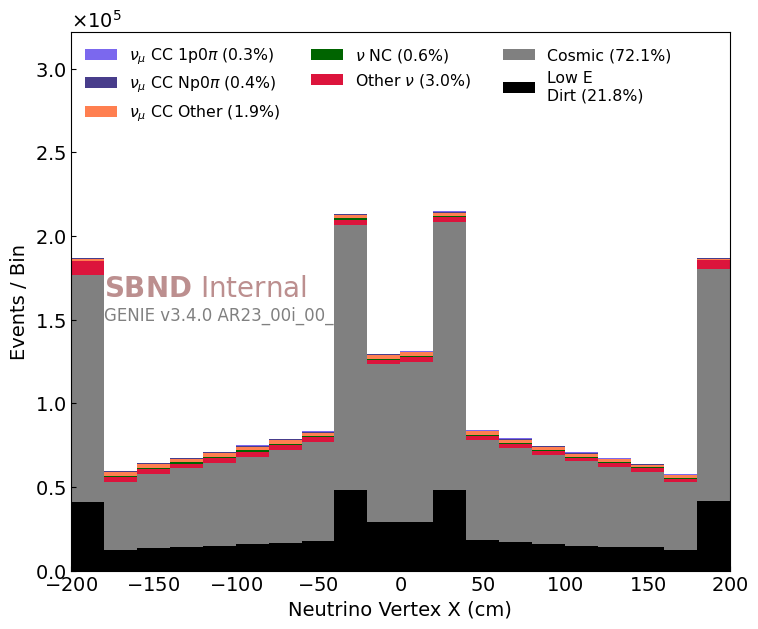

KeyError: 'Key length (7) exceeds index depth (5)'

In [21]:
# ── Stage 0: allreco (all reconstructed slices) ──────────────────────────────
stage_key = "allreco"

mc_df_sel      = mc_df.copy()
intime_df_sel  = intime_df.copy()
offbeam_df_sel = offbeam_df.copy()
dirt_df_sel    = dirt_df.copy()
data_df_sel    = data_df.copy()

mc_trk_df_sel     = match_trkdf_to_slcdf(get_valid_trks(mc_trk_df),     mc_df_sel)
intime_trk_df_sel = match_trkdf_to_slcdf(get_valid_trks(intime_trk_df), intime_df_sel)
dirt_trk_df_sel   = match_trkdf_to_slcdf(get_valid_trks(dirt_trk_df),   dirt_df_sel)

print(f"[{stage_key}]  n_events = {len(mc_df_sel):,}  |  n_tracks = {len(mc_trk_df_sel):,}")
plot_stage_geometry(stage_key, mc_df_sel, intime_df_sel, dirt_df_sel,
                    data_df=data_df_sel,
                    mc_trk_df=mc_trk_df_sel,
                    intime_trk_df=intime_trk_df_sel,
                    dirt_trk_df=dirt_trk_df_sel)

[is_clear_cosmic]  n_events = 329,147  |  n_tracks = 649,913


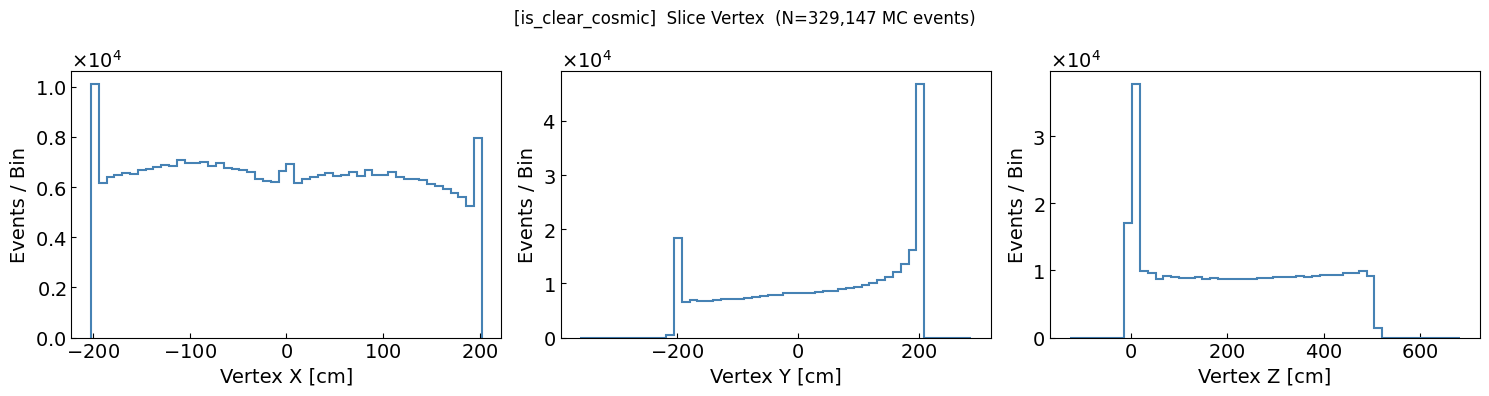

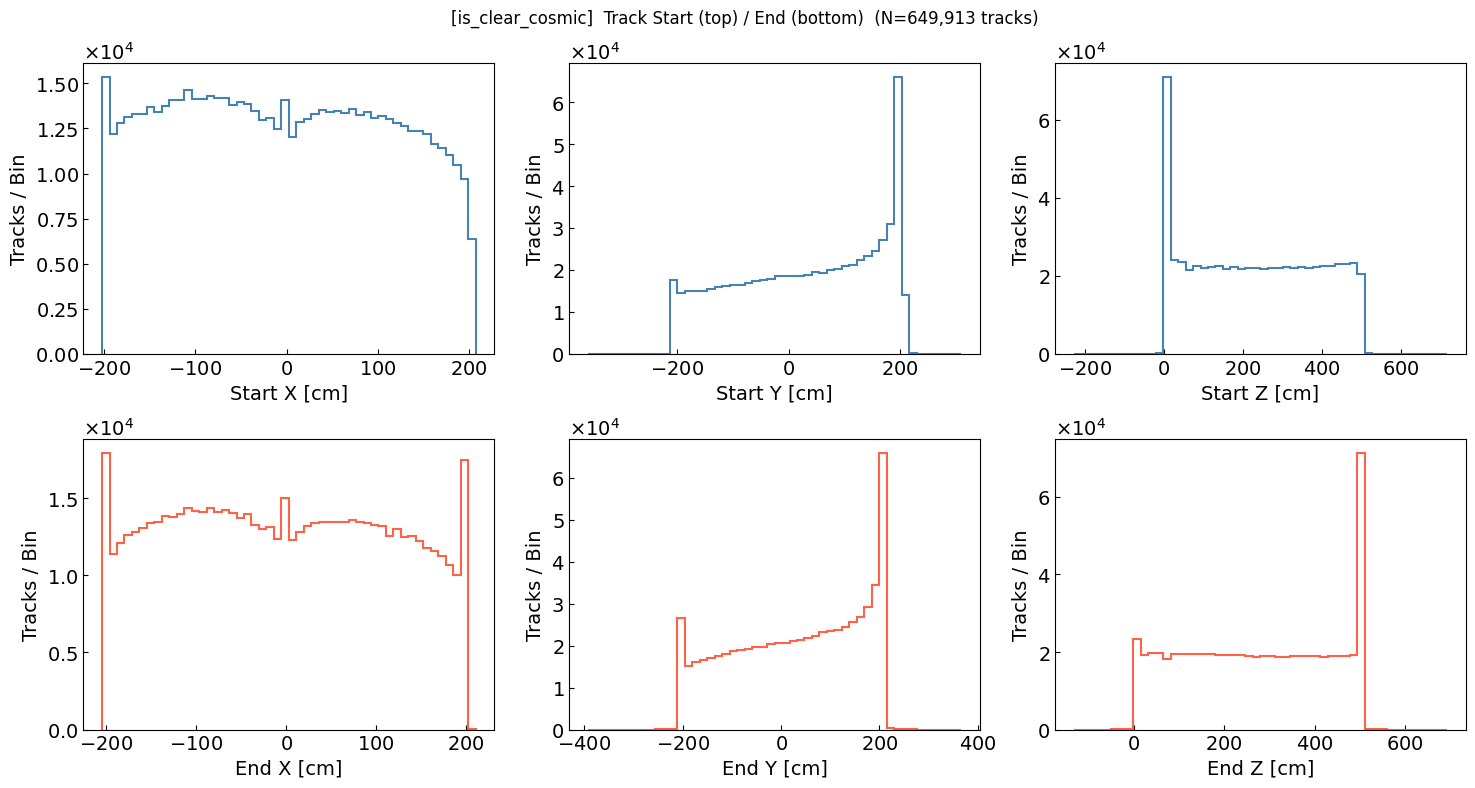

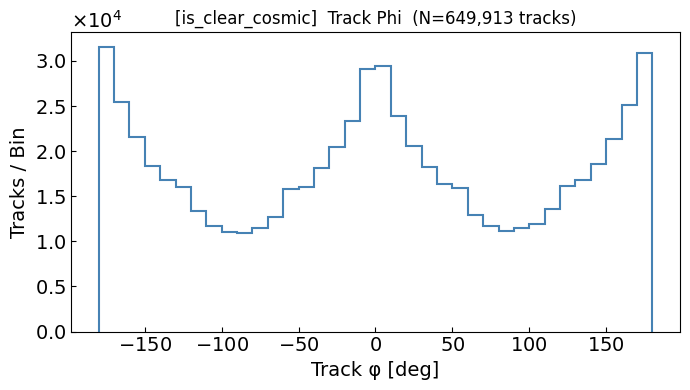

In [12]:
# ── Stage 1: is_clear_cosmic ──────────────────────────────────────────────────
stage_key = "is_clear_cosmic"

mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel = (
    cut_clear_cosmic(df)
    for df in (mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel)
)

mc_trk_df_sel     = match_trkdf_to_slcdf(get_valid_trks(mc_trk_df),     mc_df_sel)
intime_trk_df_sel = match_trkdf_to_slcdf(get_valid_trks(intime_trk_df), intime_df_sel)
dirt_trk_df_sel   = match_trkdf_to_slcdf(get_valid_trks(dirt_trk_df),   dirt_df_sel)

print(f"[{stage_key}]  n_events = {len(mc_df_sel):,}  |  n_tracks = {len(mc_trk_df_sel):,}")
plot_stage_geometry(stage_key, mc_df_sel, intime_df_sel, dirt_df_sel,
                    data_df=data_df_sel,
                    mc_trk_df=mc_trk_df_sel,
                    intime_trk_df=intime_trk_df_sel,
                    dirt_trk_df=dirt_trk_df_sel)

[vertex_in_fv]  n_events = 142,073  |  n_tracks = 328,923


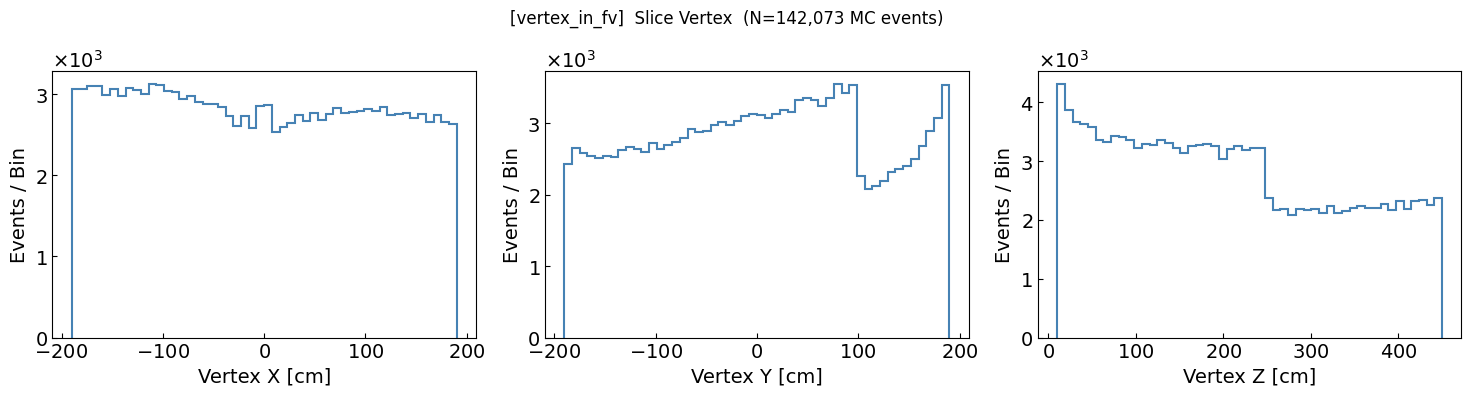

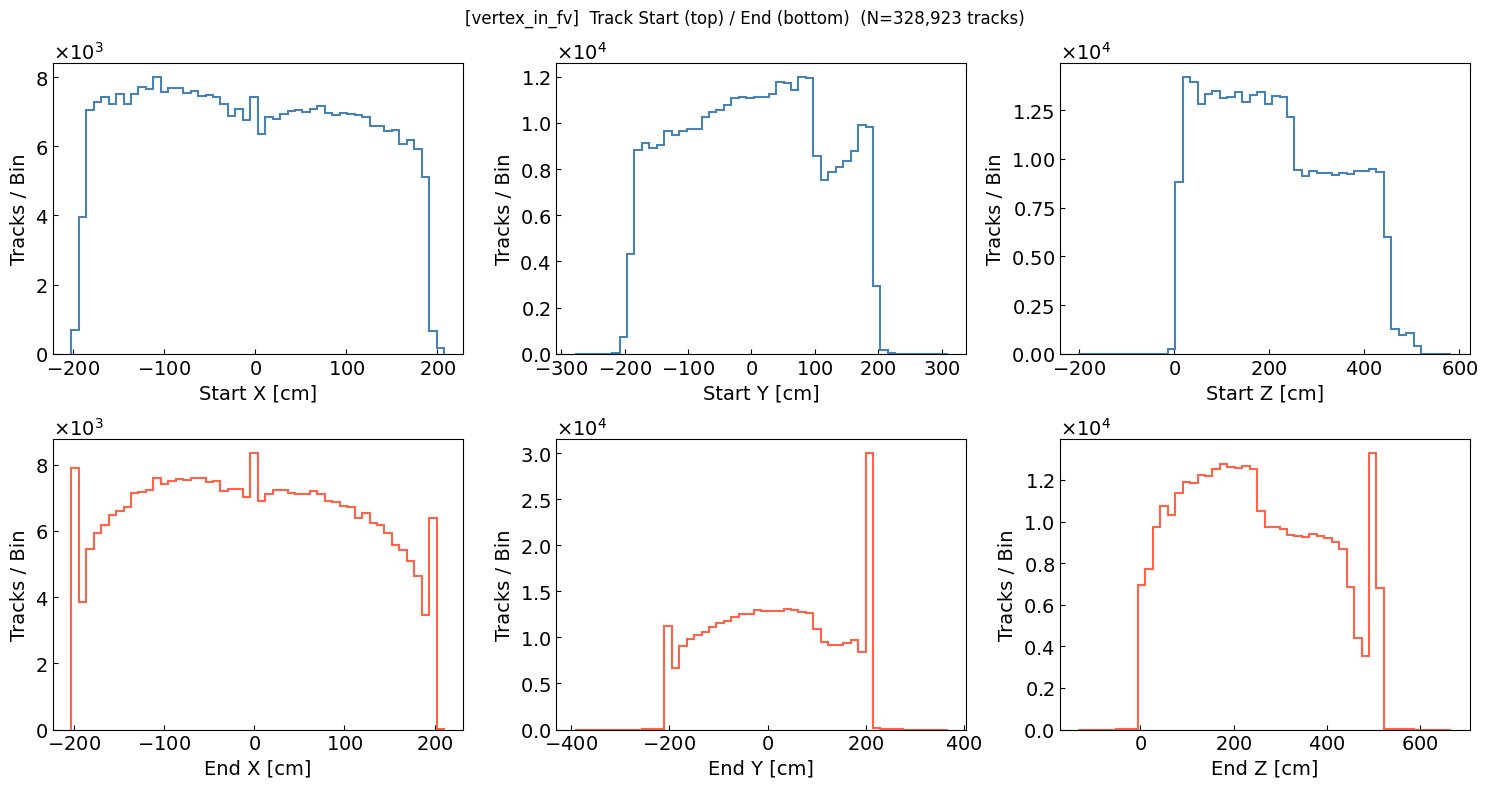

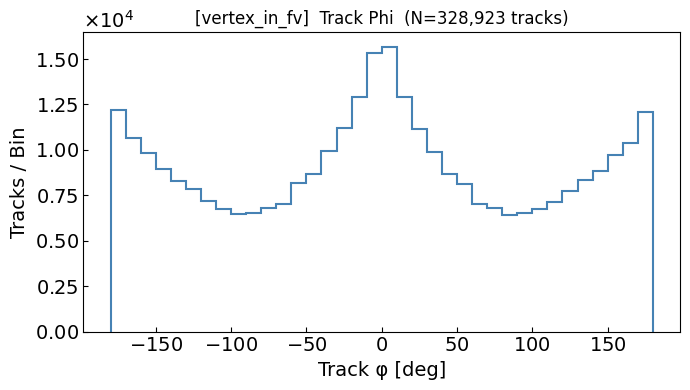

In [13]:
# ── Stage 2: vertex_in_fv ─────────────────────────────────────────────────────
stage_key = "vertex_in_fv"

mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel = (
    cut_vertex_in_fv(df, det=DETECTOR)
    for df in (mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel)
)

mc_trk_df_sel     = match_trkdf_to_slcdf(get_valid_trks(mc_trk_df),     mc_df_sel)
intime_trk_df_sel = match_trkdf_to_slcdf(get_valid_trks(intime_trk_df), intime_df_sel)
dirt_trk_df_sel   = match_trkdf_to_slcdf(get_valid_trks(dirt_trk_df),   dirt_df_sel)

print(f"[{stage_key}]  n_events = {len(mc_df_sel):,}  |  n_tracks = {len(mc_trk_df_sel):,}")
plot_stage_geometry(stage_key, mc_df_sel, intime_df_sel, dirt_df_sel,
                    data_df=data_df_sel,
                    mc_trk_df=mc_trk_df_sel,
                    intime_trk_df=intime_trk_df_sel,
                    dirt_trk_df=dirt_trk_df_sel)

In [14]:
# ── Stage 3: nu_score ─────────────────────────────────────────────────────────
stage_key = "nu_score"

mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel = (
    cut_nu_score(df, NU_SCORE_TH)
    for df in (mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel)
)

mc_trk_df_sel     = match_trkdf_to_slcdf(get_valid_trks(mc_trk_df),     mc_df_sel)
intime_trk_df_sel = match_trkdf_to_slcdf(get_valid_trks(intime_trk_df), intime_df_sel)
dirt_trk_df_sel   = match_trkdf_to_slcdf(get_valid_trks(dirt_trk_df),   dirt_df_sel)

print(f"[{stage_key}]  n_events = {len(mc_df_sel):,}  |  n_tracks = {len(mc_trk_df_sel):,}")
plot_stage_geometry(stage_key, mc_df_sel, intime_df_sel, dirt_df_sel,
                    data_df=data_df_sel,
                    mc_trk_df=mc_trk_df_sel,
                    intime_trk_df=intime_trk_df_sel,
                    dirt_trk_df=dirt_trk_df_sel)

KeyboardInterrupt: 

In [ ]:
# ── Stage 4: 2prong ───────────────────────────────────────────────────────────
# Compute per-plane-averaged chi2 PID, embed the two longest tracks into the
# event df as trk1/trk2, then require exactly two good tracks.

def prep_trks_for_2prong(trk_df, evt_df):
    """Match, filter valid tracks, compute avg chi2 and phi, return ready-to-embed df."""
    matched = match_trkdf_to_slcdf(get_valid_trks(trk_df), evt_df)
    matched[("pfp", "trk", "chi2pid", "avg", "chi2_muon",   "")] = avg_chi2(matched, "chi2_muon")
    matched[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = avg_chi2(matched, "chi2_proton")
    # Compute phi so it is embedded in trk1/trk2 by get_trk_info
    matched[("pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(matched["pfp", "trk", "dir", "x", ""],
                   matched["pfp", "trk", "dir", "y", ""])
    )
    return matched

mc_trk_df_2p    = prep_trks_for_2prong(mc_trk_df,     mc_df_sel)
intime_trk_df_2p  = prep_trks_for_2prong(intime_trk_df,  intime_df_sel)
offbeam_trk_df_2p = prep_trks_for_2prong(offbeam_trk_df, offbeam_df_sel)
dirt_trk_df_2p    = prep_trks_for_2prong(dirt_trk_df,    dirt_df_sel)
data_trk_df_2p    = prep_trks_for_2prong(data_trk_df,    data_df_sel)

mc_df_sel      = get_trk_info(mc_df_sel,      mc_trk_df_2p,    SAVE_NTRKS)
intime_df_sel  = get_trk_info(intime_df_sel,  intime_trk_df_2p,  SAVE_NTRKS)
offbeam_df_sel = get_trk_info(offbeam_df_sel, offbeam_trk_df_2p, SAVE_NTRKS)
dirt_df_sel    = get_trk_info(dirt_df_sel,    dirt_trk_df_2p,    SAVE_NTRKS)
data_df_sel    = get_trk_info(data_df_sel,    data_trk_df_2p,    SAVE_NTRKS)

stage_key = "2prong"
mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel = (
    cut_2prong(df)
    for df in (mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel)
)

print(f"[{stage_key}]  n_events = {len(mc_df_sel):,}")
plot_stage_geometry(stage_key, mc_df_sel, intime_df_sel, dirt_df_sel,
                    data_df=data_df_sel, trk_names=["trk1", "trk2"])

In [ ]:
# ── Stage 5: 2prong-contained ─────────────────────────────────────────────────
stage_key = "2prong-contained"

mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel = (
    cut_2prong_contained(df, det=DETECTOR)
    for df in (mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel)
)

print(f"[{stage_key}]  n_events = {len(mc_df_sel):,}")
plot_stage_geometry(stage_key, mc_df_sel, intime_df_sel, dirt_df_sel,
                    data_df=data_df_sel, trk_names=["trk1", "trk2"])

In [ ]:
# ── Stage 6: 2prong-trackscore ────────────────────────────────────────────────
stage_key = "2prong-trackscore"

mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel = (
    cut_2prong_trackscore(df, TRACKSCORE_TH)
    for df in (mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel)
)

print(f"[{stage_key}]  n_events = {len(mc_df_sel):,}")
plot_stage_geometry(stage_key, mc_df_sel, intime_df_sel, dirt_df_sel,
                    data_df=data_df_sel, trk_names=["trk1", "trk2"])

In [ ]:
# ── Stage 7: 2prong-vtxdist ───────────────────────────────────────────────────
stage_key = "2prong-vtxdist"

mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel = (
    cut_2prong_vtxdist(df, VTXDIST_TH)
    for df in (mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel)
)

print(f"[{stage_key}]  n_events = {len(mc_df_sel):,}")
plot_stage_geometry(stage_key, mc_df_sel, intime_df_sel, dirt_df_sel,
                    data_df=data_df_sel, trk_names=["trk1", "trk2"])

In [ ]:
# ── Stage 8: 2prong-muX (one muon-like track required) ───────────────────────
# Identify mu and p candidates then require exactly one muon-like track with
# acceptable kinematics.

stage_key = "2prong-muX"

mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel = (
    get_mu_p_candidate(
        df,
        mu_chi2mu_th=MU_CHI2MU_TH, mu_chi2p_th=MU_CHI2P_TH,
        mu_len_th=MU_LEN_TH,        qual_th=QUAL_TH,
        p_chi2mu_th=-1,             p_chi2p_th=P_CHI2P_TH,
        p_len_th=P_LEN_TH,
    )
    for df in (mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel)
)
mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel = (
    cut_has_mu(df)
    for df in (mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel)
)
mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel = (
    cut_mu_kinematics(df, mu_Plo_th=MU_PLO_TH, mu_Phi_th=MU_PHI_TH)
    for df in (mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel)
)

print(f"[{stage_key}]  n_events = {len(mc_df_sel):,}")
plot_stage_geometry(stage_key, mc_df_sel, intime_df_sel, dirt_df_sel,
                    data_df=data_df_sel, trk_names=["trk1", "trk2"])

In [ ]:
# ── Stage 9: 2prong-mup (final selected sample: μ + p) ───────────────────────
# Require a proton-like second track with acceptable kinematics.
# After this stage mc_df_sel.mu / mc_df_sel.p hold the identified candidates.

stage_key = "2prong-mup"

mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel = (
    cut_has_p(df)
    for df in (mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel)
)
mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel = (
    cut_p_kinematics(df, p_Plo_th=P_PLO_TH, p_Phi_th=P_PHI_TH)
    for df in (mc_df_sel, intime_df_sel, offbeam_df_sel, dirt_df_sel, data_df_sel)
)

print(f"[{stage_key}]  n_events = {len(mc_df_sel):,}")
# Plot the identified mu and p candidates for the final selected sample
plot_stage_geometry(stage_key, mc_df_sel, intime_df_sel, dirt_df_sel,
                    data_df=data_df_sel, trk_names=["mu", "p"])